In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [2]:
import os
base_dir = r"C:\Users\amol satpute\Desktop\new project deep learninig\chest_xray"


train_dir = base_dir + r"\train"
val_dir   = base_dir + r"\val"
test_dir  = base_dir + r"\test"

In [3]:
import os

print(os.listdir(base_dir))
print(os.listdir(train_dir))
print(os.listdir(val_dir))
print(os.listdir(test_dir))

['test', 'train', 'val']
['.DS_Store', 'NORMAL', 'PNEUMONIA']
['.DS_Store', 'NORMAL', 'PNEUMONIA']
['.DS_Store', 'NORMAL', 'PNEUMONIA']


In [4]:
# Count images in each directory
import os
folder_path=r"C:\Users\amol satpute\Desktop\new project deep learninig\Chest-Xray-2 (4)\chest_xray\test\PNEUMONIA"

def count_images(folder_path):
    counts = {}
    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

In [5]:
train_counts = count_images(train_dir)
val_counts   = count_images(val_dir)
test_counts  = count_images(test_dir)

print("DATASET SUMMARY\n")
print("Training:", train_counts, "| Total:", sum(train_counts.values()))
print("Validation:", val_counts, "| Total:", sum(val_counts.values()))
print("Test:", test_counts, "| Total:", sum(test_counts.values()))

DATASET SUMMARY

Training: {'NORMAL': 1342, 'PNEUMONIA': 3876} | Total: 5218
Validation: {'NORMAL': 9, 'PNEUMONIA': 9} | Total: 18
Test: {'NORMAL': 234, 'PNEUMONIA': 390} | Total: 624


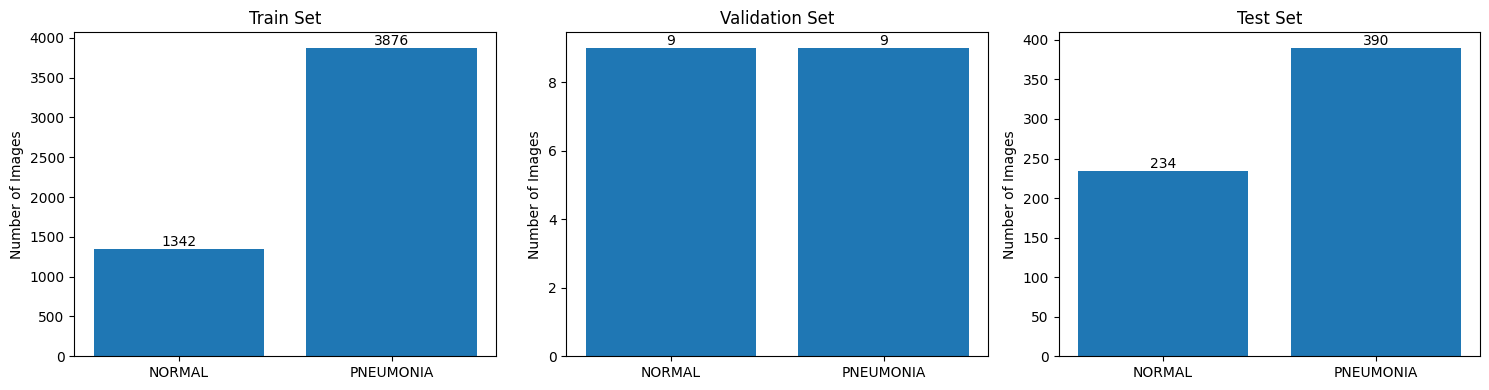

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    ("Train", train_counts),
    ("Validation", val_counts),
    ("Test", test_counts)
]

for ax, (title, counts) in zip(axes, datasets):
    ax.bar(counts.keys(), counts.values())
    ax.set_title(f"{title} Set")
    ax.set_ylabel("Number of Images")

    for i, v in enumerate(counts.values()):
        ax.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [7]:
import os
import matplotlib.pyplot as plt
from PIL import Image



In [8]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)
 # No augmentation for validation and test
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    color_mode='grayscale',
    batch_size=32,
    class_mode='binary'
)
# Validation generator
val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    color_mode='grayscale',
    batch_size=32,
    class_mode='binary'
)
 # Test generator
test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    color_mode='grayscale',
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [9]:
print(train_data.class_indices)


{'NORMAL': 0, 'PNEUMONIA': 1}


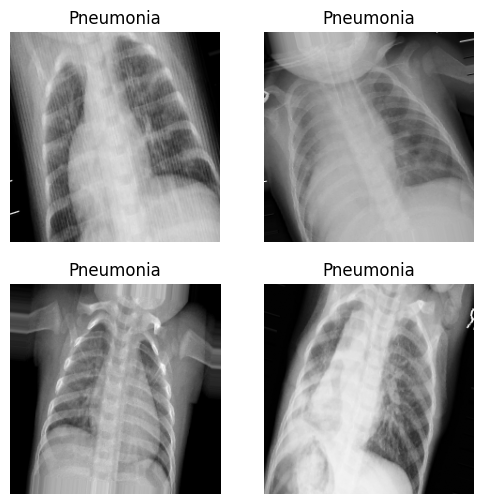

In [10]:
images, labels = next(train_data)

plt.figure(figsize=(6,6))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i].reshape(224,224), cmap='gray')
    plt.title("Pneumonia" if labels[i]==1 else "Normal")
    plt.axis('off')
plt.show()

In [ ]:
model = Sequential()

# Convolution Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,1)))
model.add(MaxPooling2D(2,2))

# Convolution Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Convolution Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Fully Connected Layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))


c:\Users\amol satpute\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

     

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 479s 3s/step - accuracy: 0.8165 - loss: 0.4052 - val_accuracy: 0.6250 - val_loss: 1.3853
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 476s 3s/step - accuracy: 0.8785 - loss: 0.2955 - val_accuracy: 0.7500 - val_loss: 0.5770
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.8967 - loss: 0.2582 - val_accuracy: 0.6875 - val_loss: 0.5956
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 800ms/step - accuracy: 0.9084 - loss: 0.2269 - val_accuracy: 0.6250 - val_loss: 1.2880
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 115s 706ms/step - accuracy: 0.9191 - loss: 0.2124 - val_accuracy: 0.7500 - val_loss: 0.6842


## Graphical representation

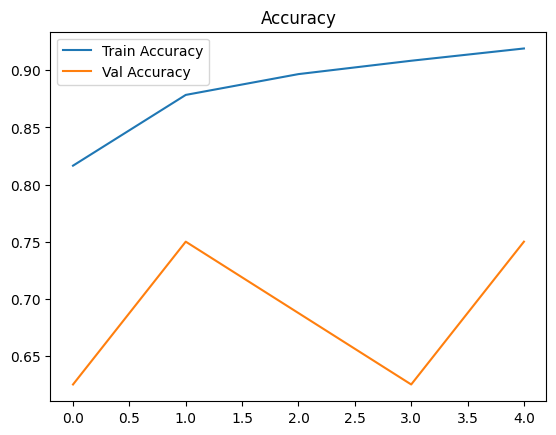

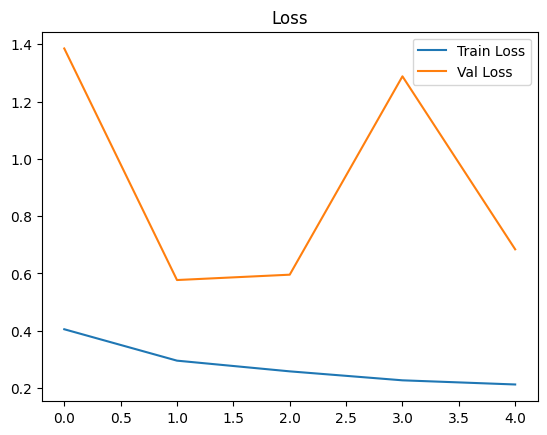

In [15]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()


In [16]:
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 380ms/step - accuracy: 0.8413 - loss: 0.4140
Test Accuracy: 0.8413461446762085


# Moldel Evaluation

In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(test_data.classes, y_pred))
print(classification_report(test_data.classes, y_pred))

     

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step
[[146  88]
 [ 11 379]]
              precision    recall  f1-score   support

           0       0.93      0.62      0.75       234
           1       0.81      0.97      0.88       390

    accuracy                           0.84       624
   macro avg       0.87      0.80      0.82       624
weighted avg       0.86      0.84      0.83       624



## Test model on new sample

In [18]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path =r"C:\Users\amol satpute\Desktop\OIP.webp"


img = image.load_img(img_path, target_size=(224,224), color_mode='grayscale')
img = image.img_to_array(img) / 255.0
img = img.reshape(1,224,224,1)

prediction = model.predict(img)

if prediction > 0.5:
    print("Pneumonia Detected")
else:
    print("Normal Chest X-ray")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Normal Chest X-ray


In [20]:
model.save('pneumonia_detection_model.h5')
